In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd().parent)
print(path)
sys.path.insert(1, path)

/home/joaquin/Documents/GitHub/skforecast


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from skforecast.experimental import ARIMA as SkfARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
from aeon.datasets import load_airline
from statsforecast.models import ARIMA
from skforecast.datasets import fetch_dataset
import warnings
import time

In [3]:
# Data set 1: Fuel Consumption
data = fetch_dataset(name='fuel_consumption', raw=True, verbose=False)
data = data[['Fecha', 'Gasolinas']]
data = data.rename(columns={'Fecha':'date', 'Gasolinas':'litters'})
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
data = data.set_index('date')
data = data.loc[:'1990-01-01 00:00:00']
data = data.asfreq('MS')
data = data[['litters']]
data = data.rename(columns={'litters': 'y'})
data['month'] = data.index.month.astype('float')
end_train = '1980-01-01 23:59:59'
data_train = data.loc[:end_train]
data_test  = data.loc[end_train:]
print(f"Train samples: {len(data_train)}")
print(f"Test samples:  {len(data_test)}")

# Data set 2: Airline Passengers
# data = load_airline(return_array=False).to_frame(name='y')
# data = data.asfreq('M')
# data['month'] = data.index.month.astype('float')
# end_train = '1957-12-01 23:59:59'
# data_train = data.loc[:end_train]
# data_test  = data.loc[end_train:]
# print(f"Train samples: {len(data_train)}")
# print(f"Test samples:  {len(data_test)}")

# Data set 3: Website Visits
# data = fetch_dataset(name="website_visits", raw=True, verbose=False)
# data['date'] = pd.to_datetime(data['date'], format='%d/%m/%y')
# data = data.set_index('date')
# data = data.asfreq('1D')
# data = data.sort_index()
# data = data.rename(columns={'users': 'y'})
# data['month'] = data.index.day_of_week.astype('float')
# end_train = '2021-06-30 23:59:00'
# data_train = data.loc[: end_train, :]
# data_test  = data.loc[end_train:, :]


# Data set 4: Airline Passengers
# data = sm.datasets.get_rdataset("AirPassengers").data
# data = data[['value']]
# data = data.rename(columns={'value': 'y'})
# data.index = pd.date_range(start='1949-01-01', periods=len(data), freq='M')
# data['month'] = data.index.month.astype('float')
# data_train = data.iloc[:120]
# data_test = data.iloc[120:]

# Data set 5: sunspots
# data = sm.datasets.sunspots.load_pandas().data
# data = data.rename(columns={'SUNACTIVITY': 'y'})
# data_train = data.iloc[:250]
# data_test = data.iloc[250:]

data

Train samples: 133
Test samples:  120


,y,month
date,,
1969-01-01,166875.2129,1.0
1969-02-01,155466.8105,2.0
1969-03-01,184983.6699,3.0
1969-04-01,202319.8164,4.0
1969-05-01,206259.1523,5.0
...,...,...
1989-09-01,687649.2852,9.0
1989-10-01,669889.1602,10.0
1989-11-01,601413.8867,11.0


<Axes: xlabel='date'>

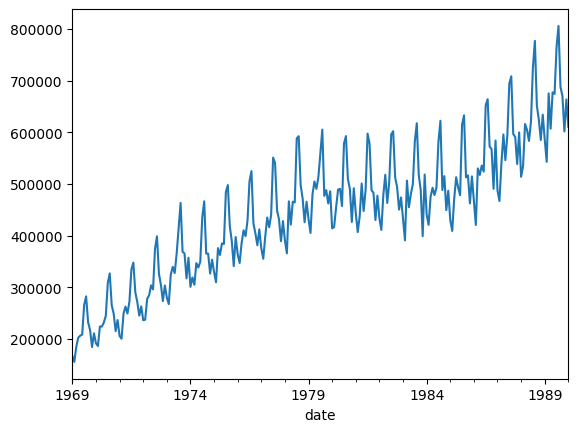

In [4]:
data['y'].plot()

In [5]:
order = (12, 1, 1)
trend = None  # 'n', 'c', 't', 'ct'
exog = data_train[['month']] # None
exog_test = data_test[['month']] # None


print("Fitting Statsmodels SARIMAX...")
warnings.filterwarnings("ignore") # Suppress convergence warnings for cleaner output
start_time = time.time()
sm_model = SARIMAX(endog=data_train['y'],
                   exog=exog,
                   order=order, 
                   trend=trend
                ) 
sm_res = sm_model.fit(disp=0)
sm_pred = sm_res.get_forecast(steps=len(data_test), exog=exog_test).predicted_mean
elapsed_time_sm = time.time() - start_time
print(f"Statsmodels fitting time: {elapsed_time_sm:.2f} seconds\n")
print(f"Model parameters:\n{sm_res.params.to_numpy()}\n")
print("")

print("Fitting Skforecast ARIMA...")
start_time = time.time()
arimax_model = SkfARIMA(order=order)
arimax_model.fit(y=data_train['y'], exog=exog)
arimax_pred_values = arimax_model.predict(steps=len(data_test), exog=exog_test)
arimax_pred = pd.Series(arimax_pred_values, index=data_test.index)
elapsed_time_skforecast = time.time() - start_time
print(f"Skforecast ARIMA fitting time: {elapsed_time_skforecast:.2f} seconds\n")
print(f"Model parameters:\n{arimax_model.ar_coef_} {arimax_model.ma_coef_} {arimax_model.intercept_}\n")
print("")

print("Fitting StatsForecast ARIMA...")
start_time = time.time()
sf_model = ARIMA(order=order)
sf_model.fit(y=data_train['y'], X=exog.to_numpy() if exog is not None else None)
sf_pred_values = sf_model.predict(h=len(data_test), X=exog_test.to_numpy() if exog_test is not None else None)
sf_pred = pd.Series(sf_pred_values['mean'], index=data_test.index)
elapsed_time_sf = time.time() - start_time
print(f"StatsForecast ARIMA fitting time: {elapsed_time_sf:.2f} seconds\n")
print(f"Model parameters:\n{[float(x) for x in sf_model.model_['coef'].values()]}\n")

Fitting Statsmodels SARIMAX...


Statsmodels fitting time: 3.98 seconds

Model parameters:
[ 3.42759419e+03  2.92659918e-02  5.84726291e-02 -2.83847019e-02
 -2.84111839e-02  4.91224203e-02 -5.62087266e-02 -1.94188547e-02
  1.64065228e-02 -1.95991996e-02 -7.83329819e-02  1.85732514e-01
  7.35662463e-01 -7.23786622e-01  5.09659162e+08]


Fitting Skforecast ARIMA...
Skforecast ARIMA fitting time: 0.43 seconds

Model parameters:
[-0.27444659 -0.14099532 -0.33380948 -0.28837135 -0.16132211 -0.38372316
 -0.29612504 -0.12755477 -0.32812278 -0.31452242 -0.06338364  0.58396238] [-0.51264235] 0.0


Fitting StatsForecast ARIMA...
Skforecast ARIMA fitting time: 0.43 seconds

Model parameters:
[-0.27444659 -0.14099532 -0.33380948 -0.28837135 -0.16132211 -0.38372316
 -0.29612504 -0.12755477 -0.32812278 -0.31452242 -0.06338364  0.58396238] [-0.51264235] 0.0


Fitting StatsForecast ARIMA...
StatsForecast ARIMA fitting time: 0.45 seconds

Model parameters:
[-0.08326699534414278, 0.37422893928099593, -0.24781660939853287, -0.1644547679

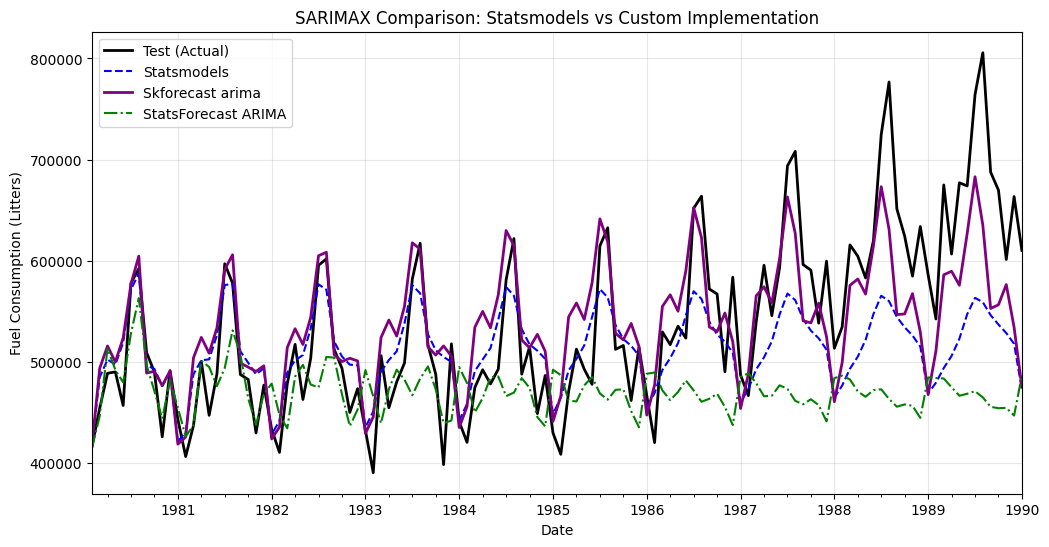

,MAE,Fitting Time (s)
Model,,
Skforecast arima,42321.478549,0.426958
Statsmodels SARIMAX,51823.942944,3.982332
StatsForecast ARIMA,80706.721548,0.449303


In [6]:
# Visualization & Comparison
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
# data_train.loc[:end_train, 'y'].plot(label='Train (Last 5 Years)', color='gray', alpha=0.5, ax=ax)
data_test['y'].plot(label='Test (Actual)', color='black', linewidth=2, ax=ax)
sm_pred.plot(label='Statsmodels', linestyle='--', color='blue', ax=ax)
arimax_pred.plot(label='Skforecast arima', linestyle='-', color='purple', linewidth=2, ax=ax)
sf_pred.plot(label='StatsForecast ARIMA', linestyle='-.', color='green', ax=ax)
plt.title('SARIMAX Comparison: Statsmodels vs Custom Implementation')
plt.xlabel('Date')
plt.ylabel('Fuel Consumption (Litters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Numerical Error Comparison
# -----------------------------------------------------------------------------
mae_sm = (data_test['y'] - sm_pred).abs().mean()
mae_sf = (data_test['y'] - sf_pred).abs().mean()
mae_arimax = (data_test['y'] - arimax_pred).abs().mean()

pd.DataFrame({
    'Model': ['Statsmodels SARIMAX', 'StatsForecast ARIMA', 'Skforecast arima'],
    'MAE': [mae_sm, mae_sf, mae_arimax],
    'Fitting Time (s)': [elapsed_time_sm, elapsed_time_sf, elapsed_time_skforecast]
}).set_index('Model').sort_values(by='MAE')

In [7]:
pd.DataFrame({
    'Statsmodels': sm_pred,
    'Custom arima': arimax_pred,
    'StatsForecast ARIMA': sf_pred
})

,Statsmodels,Custom arima,StatsForecast ARIMA
1980-02-01,418361.562460,416903.080084,414724.662707
1980-03-01,485069.653728,493865.445535,446719.291391
1980-04-01,502537.658958,515982.389627,513558.101799
1980-05-01,497547.650813,500155.987419,492278.927544
1980-06-01,519292.615710,523891.817995,479957.904816
...,...,...,...
1989-09-01,546399.763738,552995.399143,455836.840480
1989-10-01,537129.562427,556654.548952,454471.434504
1989-11-01,528723.855542,576617.518368,454832.645482
1989-12-01,518089.959930,534425.137967,447201.387059


# Comprehensive Parameter Testing

Let's test various ARIMA configurations to validate the implementation across different model complexities.

In [8]:
# Test different ARIMA configurations
import numpy as np

test_orders = [
    (1, 0, 0),   # Simple AR(1) - no differencing
    (0, 0, 1),   # Simple MA(1) - no differencing
    (1, 0, 1),   # ARMA(1,1) - no differencing
    (2, 1, 0),   # AR(2) with differencing
    (0, 1, 2),   # MA(2) with differencing
    (1, 1, 1),   # ARMA(1,1) with differencing
    (2, 1, 1),   # ARMA(2,1) with differencing
    (3, 1, 1),   # Current best (ARMA(3,1) with differencing)
    (2, 1, 2),   # ARMA(2,2) with differencing
    (1, 2, 1),   # ARMA(1,1) with second-order differencing
]

results = []

for order in test_orders:
    print(f"\nTesting ARIMA{order}...")
    
    try:
        # Custom ARIMA
        start_time = time.time()
        custom_model = SkfARIMA(order=order)
        custom_model.fit(y=data_train['y'])
        custom_pred = custom_model.predict(steps=len(data_test))
        custom_time = time.time() - start_time
        custom_mae = np.abs(data_test['y'].values - custom_pred).mean()
        
        # Statsmodels SARIMAX
        start_time = time.time()
        sm_model = SARIMAX(endog=data_train['y'], order=order, trend=None)
        sm_res = sm_model.fit(disp=0)
        sm_pred = sm_res.get_forecast(steps=len(data_test)).predicted_mean
        sm_time = time.time() - start_time
        sm_mae = np.abs(data_test['y'].values - sm_pred.values).mean()
        
        # StatsForecast ARIMA
        start_time = time.time()
        sf_model = ARIMA(order=order)
        sf_model.fit(y=data_train['y'])
        sf_pred_values = sf_model.predict(h=len(data_test))
        sf_time = time.time() - start_time
        sf_mae = np.abs(data_test['y'].values - sf_pred_values['mean']).mean()
        
        # Calculate differences
        diff_sm = np.abs(custom_pred - sm_pred.values).mean()
        diff_sf = np.abs(custom_pred - sf_pred_values['mean']).mean()
        
        results.append({
            'Order': f"ARIMA{order}",
            'skforecast MAE': custom_mae,
            'SM MAE': sm_mae,
            'SF MAE': sf_mae,
            'Diff vs SM': diff_sm,
            'Diff vs SF': diff_sf,
            'skforecast Time': custom_time,
            'SM Time': sm_time,
            'SF Time': sf_time,
        })
        
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)[:100]}")
        results.append({
            'Order': f"ARIMA{order}",
            'skforecast MAE': np.nan,
            'SM MAE': np.nan,
            'SF MAE': np.nan,
            'Diff vs SM': np.nan,
            'Diff vs SF': np.nan,
            'skforecast Time': np.nan,
            'SM Time': np.nan,
            'SF Time': np.nan,
        })

# Display results
results_df = pd.DataFrame(results)

# Helper function to highlight minimum values across a row for MAE and Time
def highlight_row_min(row):
    styles = [''] * len(row)
    
    # Find best MAE across the three models (columns 1, 2, 3)
    mae_cols = ['skforecast MAE', 'SM MAE', 'SF MAE']
    mae_values = row[mae_cols]
    if not mae_values.isna().all():
        min_mae_idx = mae_values.idxmin()
        mae_col_idx = row.index.get_loc(min_mae_idx)
        styles[mae_col_idx] = 'color: green; font-weight: bold'
    
    # Find fastest time across the three models (columns 6, 7, 8)
    time_cols = ['skforecast Time', 'SM Time', 'SF Time']
    time_values = row[time_cols]
    if not time_values.isna().all():
        min_time_idx = time_values.idxmin()
        time_col_idx = row.index.get_loc(min_time_idx)
        styles[time_col_idx] = 'color: green; font-weight: bold'
    
    return styles

# Apply styling - highlight best MAE and fastest time per row (experiment)
styled_df = results_df.style\
    .apply(highlight_row_min, axis=1)\
    .format({
        'skforecast MAE': '{:.0f}',
        'SM MAE': '{:.0f}',
        'SF MAE': '{:.0f}',
        'Diff vs SM': '{:.0f}',
        'Diff vs SF': '{:.0f}',
        'skforecast Time': '{:.3f}s',
        'SM Time': '{:.3f}s',
        'SF Time': '{:.3f}s',
    })

styled_df


Testing ARIMA(1, 0, 0)...

Testing ARIMA(0, 0, 1)...

Testing ARIMA(1, 0, 1)...

Testing ARIMA(1, 0, 1)...



Testing ARIMA(2, 1, 0)...

Testing ARIMA(0, 1, 2)...

Testing ARIMA(1, 1, 1)...

Testing ARIMA(2, 1, 1)...

Testing ARIMA(2, 1, 1)...

Testing ARIMA(3, 1, 1)...

Testing ARIMA(3, 1, 1)...

Testing ARIMA(2, 1, 2)...

Testing ARIMA(2, 1, 2)...

Testing ARIMA(1, 2, 1)...

Testing ARIMA(1, 2, 1)...


,Order,skforecast MAE,SM MAE,SF MAE,Diff vs SM,Diff vs SF,skforecast Time,SM Time,SF Time
0,"ARIMA(1, 0, 0)",176572,277700,175776,102331,796,0.017s,0.020s,0.016s
1,"ARIMA(0, 0, 1)",180667,536617,182646,355950,1978,0.001s,0.038s,0.176s
2,"ARIMA(1, 0, 1)",176304,256537,167610,83647,8694,0.001s,0.061s,0.186s
3,"ARIMA(2, 1, 0)",115481,116549,115696,1220,243,0.001s,0.027s,0.016s
4,"ARIMA(0, 1, 2)",71881,111506,100298,65854,51851,0.001s,0.048s,0.030s
5,"ARIMA(1, 1, 1)",72232,85894,84595,28039,25913,0.009s,0.151s,0.066s
6,"ARIMA(2, 1, 1)",72570,84139,82104,23755,20329,0.011s,0.190s,0.100s
7,"ARIMA(3, 1, 1)",108745,110318,108719,1882,41,0.026s,0.183s,0.082s
8,"ARIMA(2, 1, 2)",110903,78203,74410,45503,58274,0.031s,0.460s,0.062s
9,"ARIMA(1, 2, 1)",805016,72196,183423,844499,621630,0.002s,0.077s,0.028s


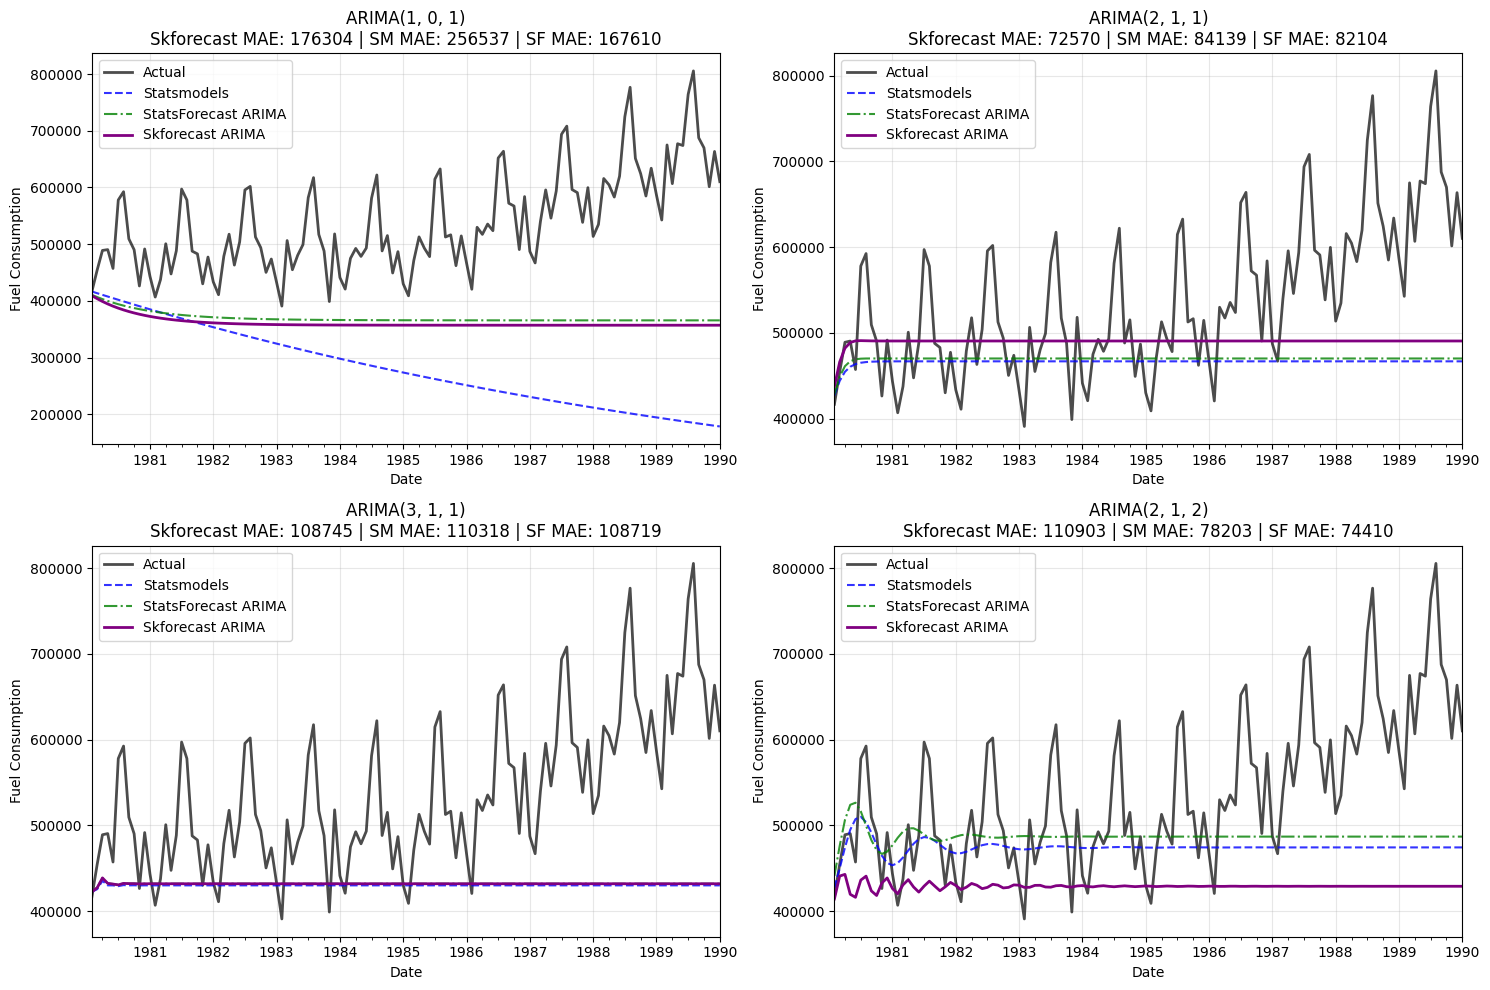

In [9]:
# Visualize best performing models
best_models = [
    (1, 0, 1),   # ARMA(1,1) - no differencing
    (2, 1, 1),   # ARMA(2,1) with differencing  
    (3, 1, 1),   # ARMA(3,1) with differencing
    (2, 1, 2),   # ARMA(2,2) with differencing
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, order in enumerate(best_models):
    ax = axes[idx]
    
    # Fit models
    custom_model = SkfARIMA(order=order)
    custom_model.fit(y=data_train['y'])
    custom_pred = custom_model.predict(steps=len(data_test))
    
    sm_model = SARIMAX(endog=data_train['y'], order=order, trend=None)
    sm_res = sm_model.fit(disp=0)
    sm_pred = sm_res.get_forecast(steps=len(data_test)).predicted_mean

    sf_model = ARIMA(order=order)
    sf_model.fit(y=data_train['y'])
    sf_pred_values = sf_model.predict(h=len(data_test))
    sf_pred = pd.Series(sf_pred_values['mean'], index=data_test.index)
    
    # Plot
    data_test['y'].plot(label='Actual', color='black', linewidth=2, ax=ax, alpha=0.7)
    sm_pred.plot(label='Statsmodels', linestyle='--', color='blue', ax=ax, alpha=0.8)
    sf_pred.plot(label='StatsForecast ARIMA', linestyle='-.', color='green', ax=ax, alpha=0.8)
    pd.Series(custom_pred, index=data_test.index).plot(
        label='Skforecast ARIMA', linestyle='-', color='purple', linewidth=2, ax=ax
    )
    
    # Calculate errors
    custom_mae = np.abs(data_test['y'].values - custom_pred).mean()
    sm_mae = np.abs(data_test['y'].values - sm_pred.values).mean()
    sf_mae = np.abs(data_test['y'].values - sf_pred.values).mean()
    
    ax.set_title(f'ARIMA{order}\nSkforecast MAE: {custom_mae:.0f} | SM MAE: {sm_mae:.0f} | SF MAE: {sf_mae:.0f}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Fuel Consumption')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()